In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [ ]:
# example session for looking at LFP
from GridMaze.analysis.core import get_sessions as gs

session = gs.get_maze_sessions(
    subject_IDs=["m3"],
    maze_names=["maze_1"],
    days_on_maze=[12],
    with_data="all",
    must_have_data=True,
)

In [ ]:
from GridMaze.analysis.lfp import traces as lt

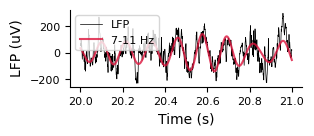

In [15]:
reload(lt)
f1, ax = plt.subplots(1, 1, figsize=(3, 1))
lt.plot_lfp_with_osc(session, window=(20, 21), freq_range=(7, 11), N=4, ax=ax)

In [31]:
from GridMaze.analysis.lfp import theta_mod as tm

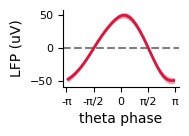

In [14]:
reload(tm)
theta_aligned_signal = tm.get_theta_aligned_lfp_df()
f2, ax = plt.subplots(1, 1, figsize=(1.5, 1))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=ax)

In [8]:
from GridMaze.analysis.event_aligned import lfp

spectrogram_df = lfp.load_spectrogram_df("LFP")

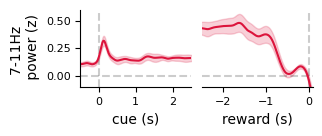

In [12]:
reload(lfp)
fig, axes = plt.subplots(1, 2, figsize=(3, 1), sharey=True)
fig.subplots_adjust(wspace=0.1)

lfp.plot_average_band_power(spectrogram_df, axes=axes)

In [ ]:
from GridMaze.analysis.lfp import theta_mod2 as tm2

theta_mod_df = tm2.get_population_theta_mod_tuning()

all neurons
                  T2          F  df1  df2      pval
hotelling  28.334779  12.750651    2    9  0.002365


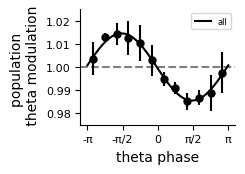

In [ ]:
reload(tm2)
fig, ax = plt.subplots(figsize=(2, 1.5))
tm2.plot_subpopulation_theta_mod(
    theta_mod_df, populations=["all"], colors=["k"], print_stats=True, ylim=(0.975, 1.025), ax=ax
)

In [41]:
from GridMaze.analysis.theta_mod import distance_to_goal_decoder as tdd

theta_mod_decoding = tdd.load_decoding_results(lfp_type="theta_mid")

None
                  T2         F  df1  df2      pval
hotelling  16.323042  7.345369    2    9  0.012838


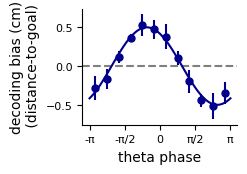

In [42]:
reload(tdd)
f, ax = plt.subplots(1, 1, figsize=(2, 1.5))
tdd.plot_decoding_theta_bias(theta_mod_decoding, ax=ax, color="darkblue", print_stats=True)

In [3]:
from GridMaze.analysis.theta_mod import distance_to_goal_tuning as tmt

In [5]:
reload(tmt)
tuning_curves, tuning_metrics = tmt.get_population_theta_split_distance_tuning(
    subject_ID="all", method="peak_trough", verbose=False
)

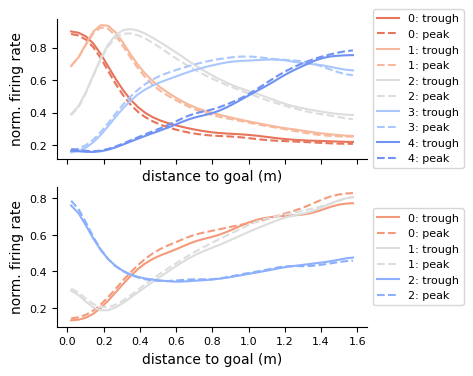

In [ ]:
f, axes = plt.subplots(2, 1, figsize=(4, 4), sharex=False)
for ax, sign, neuron_groups in zip(axes, ["pos", "neg"], [5, 3]):
    tmt.plot_heatmap_slices(
        tuning_curves,
        tuning_metrics,
        sign=sign,
        neuron_groups=neuron_groups,
        distance_groups=False,
        how="horizontal",
        cmap="coolwarm_r",
        ax=ax,
    )

In [24]:
reload(tmt)
results_df = tmt.get_population_distance_tuning_theta_x_shifts_all_phases()

In [43]:
reload(tmt)
f, ax = plt.subplots(1, 1, figsize=(2, 2))
tmt.plot_theta_mod_x_shifts(results_df, color="royalblue", ax=ax)

: 

In [ ]:
# place-dir, distance-to-goal error corr
from GridMaze.analysis.theta_mod import decoding_error_corr as dec

results_df = dec.get_decoding_error_corr_df(verbose=False)

mean=0.034, sem=0.007, t=4.230, p=0.0041


<Axes: ylabel='correlation\n(place δ ↔ distance δ)'>

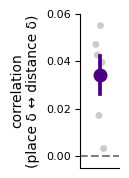

In [33]:
reload(dec)
f, ax = plt.subplots(1, 1, figsize=(0.5, 2))
dec.plot_decoding_error_corr(results_df, ax=ax)

In [ ]:
from GridMaze.analysis.theta_mod import trajectory_decoding as td

summary_df = td.get_summary_df()

None
                  T2         F  df1  df2     pval
hotelling  14.831857  6.674335    2    9  0.01669
place vs distance offset:
offset: 1.206 ± 0.303. Rayleigh test: z=3.464, p=0.024


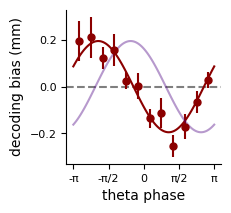

In [37]:
reload(td)
f, ax = plt.subplots(1, 1, figsize=(2, 2))
td.plot_theta_mod_trajectory_error(summary_df, ax=ax)

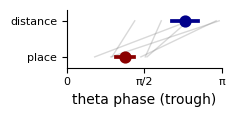

In [ ]:
reload(td)
f, ax = plt.subplots(1, 1, figsize=(1, 0.75))
td.plot_trough_phases(summary_df, ax=ax)

## Supp.

In [ ]:
from GridMaze.analysis.processing import get_lfp_aligned_spike_counts as asc

array([<Axes: ylabel='LFP (uV)'>, <Axes: ylabel='theta 7-11Hz (uV)'>,
       <Axes: ylabel='cluster'>,
       <Axes: xlabel='Time (s)', ylabel='cluster\n(θ bin 1)'>],
      dtype=object)

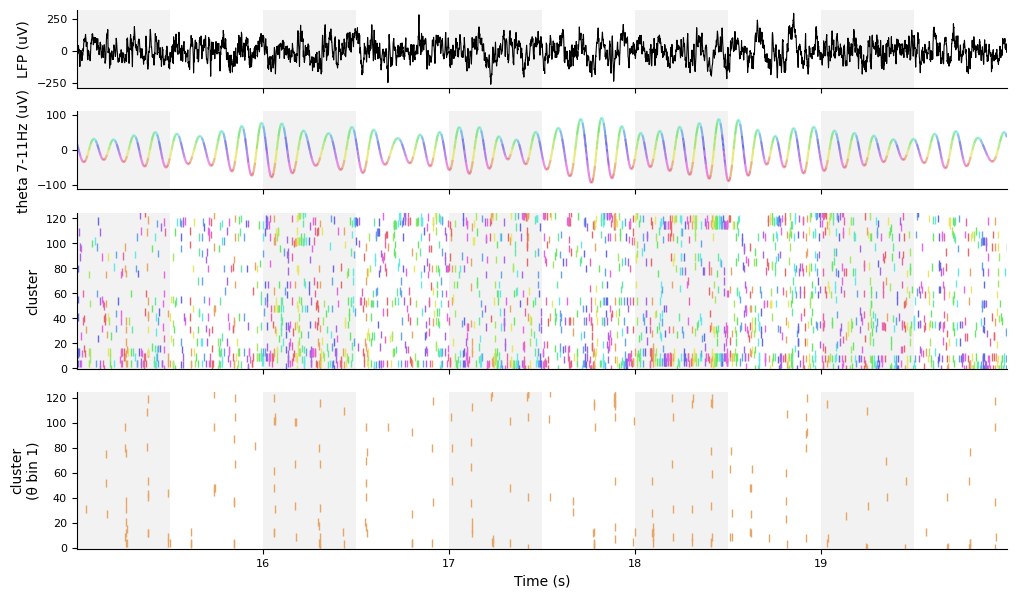

In [30]:
reload(asc)
f, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True, height_ratios=[1, 1, 2, 2])
asc.plot_theta_phase_stratified_spikes(session, time_window=(15, 20), axes=axes, cmap=None)

<Axes: >

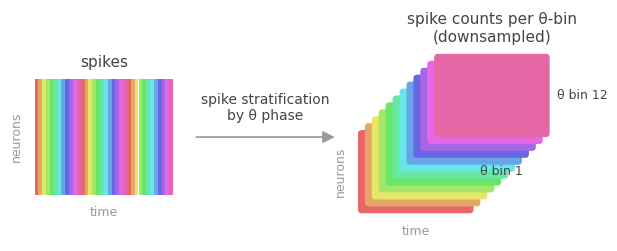

In [29]:
reload(asc)
f, ax = plt.subplots(1, 1, figsize=(9, 3))
asc.plot_theta_stratification_schematic(cmap=None, ax=ax)

In [ ]:
fig, ax = plt.subplots(figsize=(2, 1.5))
tm2.plot_subpopulation_theta_mod(
    theta_mod_df,
    populations=["all", "place_direction", "distance_to_goal"],
    colors=["k", "darkred", "darkblue"],
    print_stats=True,
    ylim=(0.975, 1.025),
    ax=ax,
)